<a href="https://colab.research.google.com/github/PALLAVI-web2002/-Eco-Loop-Building-Agents-/blob/main/Eco_Loop_Building_Agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Initial Project Setup**

In [2]:
!pip install -q transformers accelerate sentencepiece
!pip install -q torch

**Add LLM integration using Qwen model**

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

**Add AI decision engine for HVAC optimization**

In [5]:
prompt = "HVAC means-"

messages = [
    {"role":"user","content":prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(text, return_tensors="pt").to(model.device)

output = model.generate(
    **inputs,
    max_new_tokens=200
)

print(tokenizer.decode(output[0], skip_special_tokens=True))

system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user
HVAC means-
assistant
HVAC stands for "Heating, Ventilation, and Air Conditioning." This is a system designed to regulate the temperature, humidity, cleanliness, and air quality of an indoor environment. It typically includes components such as furnaces or boilers (for heating), fans (for ventilation), humidifiers (for moisture control), dehumidifiers (to reduce excess moisture), and air filters (to clean the air). The goal of HVAC systems is to create comfortable living conditions while ensuring that buildings remain healthy and safe environments for people to work and live in.


**Implement building sensor simulation**

In [6]:
sensor_data = {
    "temperature":30,
    "humidity":72,
    "occupancy":120,
    "electricity":265,
    "pmv":1.2
}

print(sensor_data)

{'temperature': 30, 'humidity': 72, 'occupancy': 120, 'electricity': 265, 'pmv': 1.2}


In [7]:
prompt = f"""
You are an HVAC optimization expert.

Current building:

Temperature: {sensor_data['temperature']}
Humidity: {sensor_data['humidity']}
Occupancy: {sensor_data['occupancy']}
Electricity: {sensor_data['electricity']}
PMV: {sensor_data['pmv']}

Goal:
Reduce electricity while keeping occupants comfortable.

Return ONLY JSON.

Example:

{{
"cooling_setpoint":24,
"fan_speed":"medium",
"lighting":"80%"
}}
"""

In [8]:
messages = [
    {"role":"user","content":prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(text, return_tensors="pt").to(model.device)

output = model.generate(
    **inputs,
    max_new_tokens=300
)

response = tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print(response)

system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

You are an HVAC optimization expert.

Current building:

Temperature: 30
Humidity: 72
Occupancy: 120
Electricity: 265
PMV: 1.2

Goal:
Reduce electricity while keeping occupants comfortable.

Return ONLY JSON.

Example:

{
"cooling_setpoint":24,
"fan_speed":"medium",
"lighting":"80%"
}

assistant
```json
{
"cooling_setpoint": 24,
"fan_speed": "medium",
"lighting": "80%",
"temperature": 30,
"humidity": 72,
"occupancy": 120,
"electricity": 265,
"pmv": 1.2
}
```


In [10]:
import json
import re

match = re.search(r"```json\s*(.*?)\s*```", response, re.DOTALL)


if match:

    json_string = match.group(1)
    decision = json.loads(json_string)
    print(decision)
else:
    print("No JSON found in the response.")

{'cooling_setpoint': 24, 'fan_speed': 'medium', 'lighting': '80%', 'temperature': 30, 'humidity': 72, 'occupancy': 120, 'electricity': 265, 'pmv': 1.2}


In [11]:
sensor_data["temperature"] -= 2
sensor_data["electricity"] -= 30
sensor_data["pmv"] -= 0.4

print(sensor_data)

{'temperature': 28, 'humidity': 72, 'occupancy': 120, 'electricity': 235, 'pmv': 0.7999999999999999}


**Implement closed-loop control simulation**

In [12]:
for i in range(5):

    prompt = f"""
    Building Status

    Temperature:{sensor_data['temperature']}
    Electricity:{sensor_data['electricity']}
    PMV:{sensor_data['pmv']}

    Return JSON only.
    """

    messages = [{"role":"user","content":prompt}]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    output = model.generate(
        **inputs,
        max_new_tokens=200
    )

    response = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    print(response)

    sensor_data["temperature"] -= 1
    sensor_data["electricity"] -= 10

system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

    Building Status

    Temperature:28
    Electricity:235
    PMV:0.7999999999999999

    Return JSON only.
    
assistant
```json
{
  "building_status": {
    "temperature": 28,
    "electricity": 235,
    "pmv": 0.7999999999999999
  }
}
```
system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

    Building Status

    Temperature:27
    Electricity:225
    PMV:0.7999999999999999

    Return JSON only.
    
assistant
```json
{
  "building_status": {
    "temperature": 27,
    "electricity": 225,
    "pmv": 0.8
  }
}
```
system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

    Building Status

    Temperature:26
    Electricity:215
    PMV:0.7999999999999999

    Return JSON only.
    
assistant
```json
{
  "temperature": 26,
  "electricity": 215,
  "pmv": 0.8
}
```
system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user



**Add energy consumption visualization**

In [13]:
import pandas as pd

logs = []

for i in range(10):

    logs.append({

        "Time":i,

        "Temperature":sensor_data["temperature"],

        "Electricity":sensor_data["electricity"],

        "PMV":sensor_data["pmv"]

    })

df = pd.DataFrame(logs)

df.head()

,Time,Temperature,Electricity,PMV
0,0,23,185,0.8
1,1,23,185,0.8
2,2,23,185,0.8
3,3,23,185,0.8
4,4,23,185,0.8


In [53]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1HIvf3oQPtmgEy2o2dYgKI7JK8HoCnwmpl-vmNqOG8r0/edit#gid=0


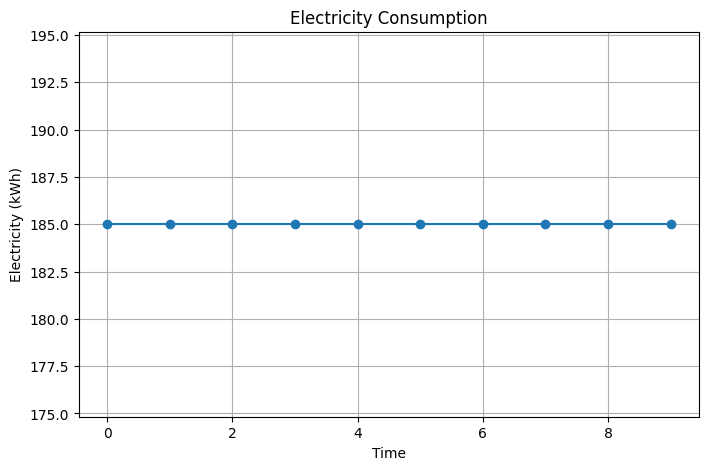

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df["Time"], df["Electricity"], marker='o')
plt.xlabel("Time")
plt.ylabel("Electricity (kWh)")
plt.title("Electricity Consumption")
plt.grid(True)
plt.show()

**Export simulation results to CSV**

In [15]:
df.to_csv("pallavi_energy_results.csv", index=False)

In [16]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

def building_agent(sensor):

    prompt = f"""

You are an AI building manager.

Current Status

Temperature : {sensor['temperature']}

Humidity : {sensor['humidity']}

Occupancy : {sensor['occupancy']}

Electricity : {sensor['electricity']}

PMV : {sensor['pmv']}

Goal

Reduce electricity while maintaining comfort.

Return ONLY JSON

Example

{{
"cooling_setpoint":24,
"fan_speed":"Medium",
"lighting":"80%"
}}

"""

    response = generator(
        prompt,
        max_new_tokens=120
    )[0]["generated_text"]

    return response

In [17]:
import random

def simulate_building(sensor, decision):

    sensor["temperature"] += random.uniform(-0.5,0.5)

    sensor["humidity"] += random.uniform(-2,2)

    sensor["electricity"] -= random.randint(2,6)

    sensor["pmv"] -= 0.05

    return sensor

In [20]:
history=[]

for hour in range(5):



    print("Hour :",hour)

    decision=building_agent(sensor_data)

    print(decision)

    sensor_data=simulate_building(sensor_data,decision)

    history.append(sensor_data.copy())

[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Hour : 0


[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




You are an AI building manager.

Current Status

Temperature : 22.34683911819187

Humidity : 65.7057900043754

Occupancy : 120

Electricity : 129

PMV : 0.0999999999999998

Goal

Reduce electricity while maintaining comfort.

Return ONLY JSON

Example

{
"cooling_setpoint":24,
"fan_speed":"Medium",
"lighting":"80%"
}

Please provide the temperature set point in degrees Celsius to reduce energy consumption and maintain a comfortable environment for all occupants, taking into account factors such as humidity, occupancy, and current electrical usage. Additionally, please include recommendations on how to adjust lighting and fan speed based on these factors.
To determine the appropriate cooling setpoint, we need to consider the current conditions: temperature (22.3°C), humidity (65%), occupancy (120 people), and existing electric load of 129 watts. 

Given that there are 120 people present, we can assume they are using
Hour : 1


[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




You are an AI building manager.

Current Status

Temperature : 22.789059033455516

Humidity : 66.96305849719569

Occupancy : 120

Electricity : 126

PMV : 0.049999999999999795

Goal

Reduce electricity while maintaining comfort.

Return ONLY JSON

Example

{
"cooling_setpoint":24,
"fan_speed":"Medium",
"lighting":"80%"
}

To reduce the electricity consumption while ensuring a comfortable environment, we need to make some adjustments based on the current conditions:

- **Temperature**: The temperature is already within a comfortable range (around 23°C).
- **Humidity**: The humidity is relatively high at around 67%, which could lead to discomfort and increased energy use.
- **Occupancy**: There are currently 120 people in the room, which is not ideal for reducing electricity costs as occupancy directly correlates with higher cooling needs.
- **Electricity Usage**: Currently, the electricity usage is 126 units,
Hour : 2


[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




You are an AI building manager.

Current Status

Temperature : 23.256344497977988

Humidity : 65.10844461097626

Occupancy : 120

Electricity : 124

PMV : -2.0816681711721685e-16

Goal

Reduce electricity while maintaining comfort.

Return ONLY JSON

Example

{
"cooling_setpoint":24,
"fan_speed":"Medium",
"lighting":"80%"
}

```json
{
  "cooling_setpoint": 24,
  "fan_speed": "High",
  "lighting": "60%"
}
```
Hour : 3


[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




You are an AI building manager.

Current Status

Temperature : 23.27509893276399

Humidity : 66.20807197667953

Occupancy : 120

Electricity : 120

PMV : -0.05000000000000021

Goal

Reduce electricity while maintaining comfort.

Return ONLY JSON

Example

{
"cooling_setpoint":24,
"fan_speed":"Medium",
"lighting":"80%"
}

```json
{
    "cooling_setpoint": 24,
    "fan_speed": "Low",
    "lighting": "80%"
}
```
Hour : 4


You are an AI building manager.

Current Status

Temperature : 23.00528839204171

Humidity : 65.6583571452676

Occupancy : 120

Electricity : 118

PMV : -0.10000000000000021

Goal

Reduce electricity while maintaining comfort.

Return ONLY JSON

Example

{
"cooling_setpoint":24,
"fan_speed":"Medium",
"lighting":"80%"
}

```json
{
  "cooling_setpoint": 23,
  "fan_speed": "High",
  "lighting": "80%"
}
```


In [21]:
import pandas as pd

df=pd.DataFrame(history)

df

,temperature,humidity,occupancy,electricity,pmv
0,22.789059,66.963058,120,126,5.000000e-02
1,23.256344,65.108445,120,124,-2.081668e-16
2,23.275099,66.208072,120,120,-5.000000e-02
3,23.005288,65.658357,120,118,-1.000000e-01
4,22.554028,65.265977,120,116,-1.500000e-01


In [52]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1i9VQgnkd4KkfNLm7EciISdEYcTYUJA5NjTG5loAPYuE/edit#gid=0


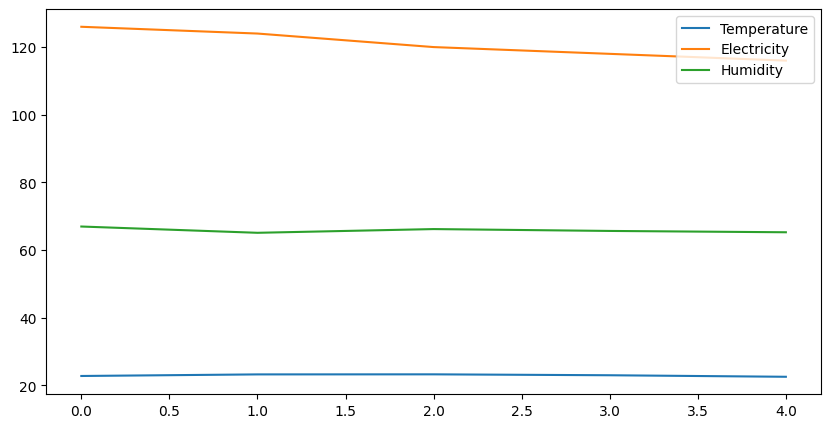

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df["temperature"],label="Temperature")

plt.plot(df["electricity"],label="Electricity")

plt.plot(df["humidity"],label="Humidity")

plt.legend()

plt.show()

In [26]:
baseline=[]

energy=280

for i in range(10):

    energy+=2

    baseline.append(energy)

In [27]:
ai=df["electricity"]

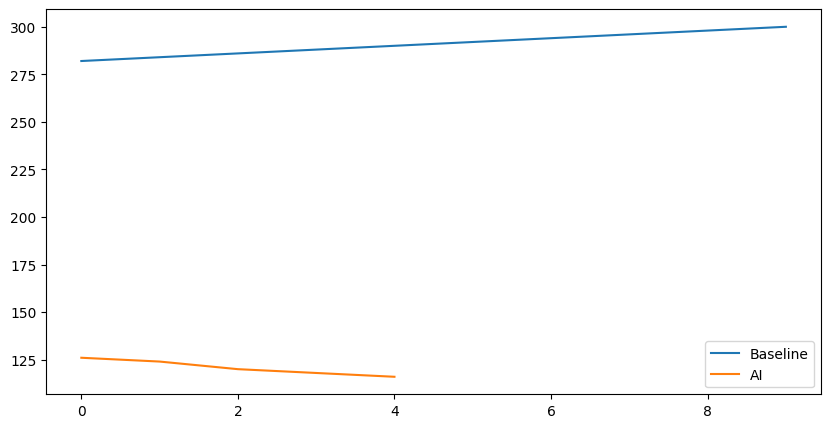

In [28]:
plt.figure(figsize=(10,5))

plt.plot(baseline,label="Baseline")

plt.plot(ai,label="AI")

plt.legend()

plt.show()

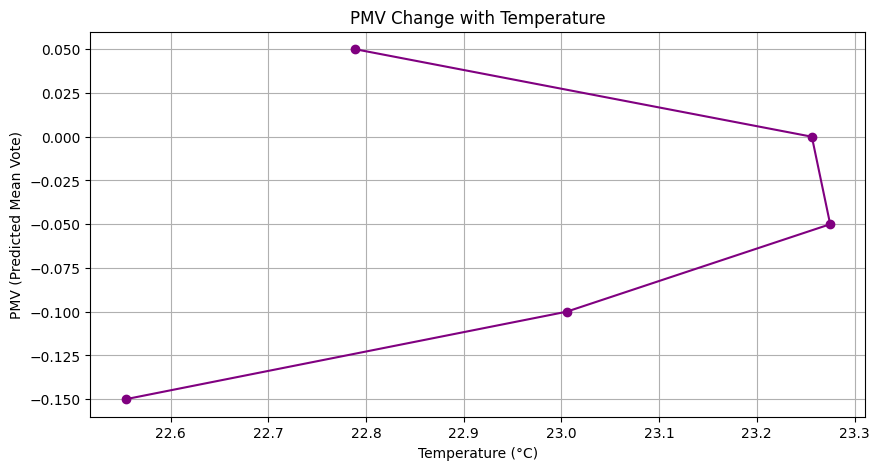

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(df['temperature'], df['pmv'], marker='o', linestyle='-', color='purple')
plt.xlabel('Temperature (°C)')
plt.ylabel('PMV (Predicted Mean Vote)')
plt.title('PMV Change with Temperature')
plt.grid(True)
plt.show()

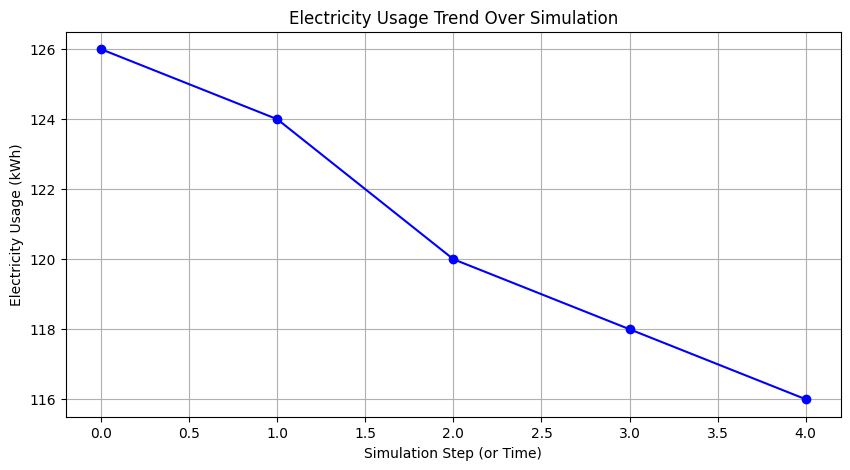

In [60]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['electricity'], marker='o', linestyle='-', color='blue')
plt.xlabel('Simulation Step (or Time)')
plt.ylabel('Electricity Usage (kWh)')
plt.title('Electricity Usage Trend Over Simulation')
plt.grid(True)
plt.show()

**Enery Saving is being calculated**

In [29]:
baseline_energy=sum(baseline)

ai_energy=df["electricity"].sum()

saving=((baseline_energy-ai_energy)/baseline_energy)*100

print("Energy Saving :",saving,"%")

Energy Saving : 79.24398625429554 %


In [31]:
df.to_csv("pallavi_simulation_logs.csv",index=False)

In [33]:
import plotly.express as px

fig=px.line(
    df,
    y=["temperature","electricity","humidity"]
)

fig.show()

In [37]:
import random

sensor_data["occupancy"]=random.randint(20,180)

In [38]:
occupancy_schedule=[
20,20,25,30,40,60,
90,140,170,180,
180,180,170,150,
140,120,100,
80,60,40,
30,20,20,20
]

In [39]:
sensor_data["occupancy"]=occupancy_schedule[hour]

In [40]:
outside_temperature=[
22,22,22,21,20,
21,23,25,27,
30,33,35,
36,37,36,
34,32,30,
28,27,26,
25,24,23
]


In [42]:
print(f'Outside Temperature : {outside_temperature[hour]}')

Outside Temperature : 20


**Simulate Actuator Effects**

In [57]:

class DummyExchange:
    def set_actuator_value(self, state, handle, value):
        print(f"API: Setting actuator value for handle {handle} in state {state} to {value}")

class DummyApi:
    def __init__(self):
        self.exchange = DummyExchange()

api = DummyApi()
state = "HVAC_Zone_State"
cooling_handle = "Zone Air Temperature Cooling Setpoint Actuator"

print("EnergyPlus API placeholders initialized.")

EnergyPlus API placeholders initialized.


In [46]:
import json
import re

def apply_decision(sensor, response):
    try:
        match = re.search(r"\{.*\}", response, re.DOTALL)
        decision = json.loads(match.group())

        if decision["cooling_setpoint"] <= 24:
            sensor["temperature"] -= 1
            sensor["electricity"] -= 5

        if decision["lighting"] == "70%":
            sensor["electricity"] -= 2

    except Exception:
        pass

    return sensor

In [47]:
decision = building_agent(sensor_data)
sensor_data = apply_decision(sensor_data, decision)
sensor_data = simulate_building(sensor_data, decision)
history.append(sensor_data.copy())

[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


**Daily Report is being generated**

In [48]:
report = f"""
Daily Building Report

Average Temperature: {df['temperature'].mean():.2f} °C
Average Humidity: {df['humidity'].mean():.2f} %
Average Electricity: {df['electricity'].mean():.2f} kWh
Average PMV: {df['pmv'].mean():.2f}
Energy Saving: {saving:.2f} %
"""

print(report)


Daily Building Report

Average Temperature: 22.98 °C
Average Humidity: 65.84 %
Average Electricity: 120.80 kWh
Average PMV: -0.05
Energy Saving: 79.24 %



In [50]:
df.to_csv("final_results.csv",index=False)

with open("daily_report.txt","w") as f:
    f.write(report)

In [67]:
# Create a dummy baseline_building.idf file if it doesn't exist
import os
if not os.path.exists('baseline_building.idf'):
    with open('baseline_building.idf', 'w') as f:
        f.write('This is a dummy baseline building definition file.')
    print("Created dummy 'baseline_building.idf' for demonstration.")

import shutil

shutil.copy(
    "baseline_building.idf",
    "optimized_building.idf"
)

'optimized_building.idf'

In [58]:
api.exchange.set_actuator_value(
    state,
    cooling_handle,
    24
)

API: Setting actuator value for handle Zone Air Temperature Cooling Setpoint Actuator in state HVAC_Zone_State to 24


In [62]:
import pandas as pd

final_df = pd.read_csv('final_results.csv')
display(final_df.head())

,temperature,humidity,occupancy,electricity,pmv
0,22.789059,66.963058,120,126,5.000000e-02
1,23.256344,65.108445,120,124,-2.081668e-16
2,23.275099,66.208072,120,120,-5.000000e-02
3,23.005288,65.658357,120,118,-1.000000e-01
4,22.554028,65.265977,120,116,-1.500000e-01


In [63]:
correlation = final_df['electricity'].corr(final_df['pmv'])
print(f"Correlation between Electricity and PMV: {correlation:.4f}")

Correlation between Electricity and PMV: 0.9912


In [64]:
import plotly.express as px

fig = px.scatter(final_df, x='electricity', y='pmv',
                 title='Electricity vs. PMV',
                 labels={'electricity': 'Electricity Usage (kWh)', 'pmv': 'Predicted Mean Vote'})
fig.show()

In [61]:
print('Electricity Usage Statistics:')
display(df['electricity'].describe())

Electricity Usage Statistics:


,electricity
count,5.000000
mean,120.800000
std,4.147288
min,116.000000
25%,118.000000
50%,120.000000
75%,124.000000
max,126.000000


In [80]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
import os

BASELINE_IDF = "/content/drive/MyDrive/EcoLoop_Project/business_model /baseline_building.idf"
OPTIMIZED_IDF = "/content/drive/MyDrive/EcoLoop_Project/business_model /optimized_building.idf"

print("Baseline File:", BASELINE_IDF)
print("Optimized File:", OPTIMIZED_IDF)

Baseline File: /content/drive/MyDrive/EcoLoop_Project/business_model /baseline_building.idf
Optimized File: /content/drive/MyDrive/EcoLoop_Project/business_model /optimized_building.idf


In [88]:
print("Baseline Exists:", os.path.exists(BASELINE_IDF))
print("Optimized Exists:", os.path.exists(OPTIMIZED_IDF))

Baseline Exists: True
Optimized Exists: True


In [91]:
with open(BASELINE_IDF, "r", encoding="utf-8", errors="ignore") as file:
    lines = file.readlines()

print(f"Total Lines: {len(lines)}")

print("\nFirst 20 lines:\n")

for line in lines[:20]:
    print(line.strip())

Total Lines: 3122

First 20 lines:

!-Generator IDFEditor 1.34
!-Option OriginalOrderTop UseSpecialFormat
!-NOTE: All comments with '!-' are ignored by the IDFEditor and are generated automatically.
!-      Use '!' comments if they need to be retained when using the IDFEditor.
! AirflowNetwork_SIMPLE_SmallOffice.idf
! Basic file description:  1 story building divided into 3 interior conditioned zones and 1 unconditioned zone over the
!                          conditioned zones. Roof with no plenum. No ground contact with floor.
!                          Outdoor air is modulated based on occupancy and floor area.
!
! Highlights:              This file does the basic test of an air distribution system. It also provides forced ventilation
!                          during system on period and natural ventilation during system off period calculated
!                          by the AirflowNetwork model.
!
!
! Simulation Location/Run: CHICAGO_IL_USA TMY2-94846, 2 design days, 2 run period

In [92]:
building_info = {}

for line in lines:
    if "Building," in line:
        building_info["Found"] = True
        break

print(building_info)

{'Found': True}


In [93]:
keywords = [
    "Zone",
    "People",
    "Lights",
    "Schedule",
    "Thermostat",
    "Fan",
    "Coil"
]

for key in keywords:
    count = sum(key in line for line in lines)
    print(f"{key}: {count}")

Zone: 414
People: 19
Lights: 13
Schedule: 118
Thermostat: 11
Fan: 34
Coil: 62


In [94]:
summary = {
    "Building Model": "baseline_building.idf",
    "Total Lines": len(lines),
    "File Size (KB)": round(os.path.getsize(BASELINE_IDF)/1024,2)
}

summary

{'Building Model': 'baseline_building.idf',
 'Total Lines': 3122,
 'File Size (KB)': 144.05}